In [1]:
from pathlib import Path
from typing import List, Optional, Tuple, Set, Dict
import io
import fitz  # PyMuPDF
import cv2
import numpy as np
from math import atan2, degrees, hypot, ceil
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
import uuid

try:
    from PIL import Image  # only needed for JPEG encoding
    _HAS_PIL = True
except Exception:
    _HAS_PIL = False


# Setup

In [2]:
def read_file_as_binary(file_path):
    """
    Reads a local file and returns its binary content.
    
    Args:
        file_path (str): Path to the file.
    
    Returns:
        bytes: Binary content of the file.
    """
    with open(file_path, "rb") as f:
        binary_data = f.read()
    return binary_data

In [3]:
def pdf_bytes_to_images(
    pdf_bytes: bytes,
    dpi: int = 200,
    fmt: str = "png",                   # "png" or "jpg"
    save_dir: Optional[Path | str] = None,
    base_filename: Optional[str] = None,  # used for saved filenames only
    jpg_quality: int = 90
) -> List[bytes]:
    """
    Render each page of a (scanned) PDF (given as bytes) to images and return a list of image bytes.
    Optionally save images to disk as <base_filename>_p<page>.<ext> (1-based page numbering).

    Args:
        pdf_bytes: Raw bytes of the PDF.
        dpi: Output DPI (controls resolution). 72 dpi == 1.0 zoom.
        fmt: "png" (native via PyMuPDF) or "jpg".
        save_dir: If provided, images are also saved to this directory.
        base_filename: If saving, the basename to use (default: "document").
        jpg_quality: JPEG quality (1–95) if fmt="jpg".

    Returns:
        List of bytes objects, one per page, in the requested format.
    """
    fmt = fmt.lower()
    if fmt not in {"png", "jpg", "jpeg"}:
        raise ValueError("fmt must be 'png' or 'jpg'")

    if fmt in {"jpg", "jpeg"} and not _HAS_PIL:
        raise RuntimeError("JPEG output requires Pillow (pip install Pillow)")

    # Prepare output directory (optional)
    out_dir: Optional[Path] = None
    if save_dir is not None:
        out_dir = Path(save_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        if not base_filename:
            base_filename = "document"

    if not base_filename:
        base_filename = "document"

    # DPI -> zoom factor
    zoom = dpi / 72.0
    mat = fitz.Matrix(zoom, zoom)

    images: List[bytes] = []

    # Open from bytes
    with fitz.open(stream=pdf_bytes, filetype="pdf") as doc:
        if doc.needs_pass:
            raise RuntimeError("This PDF is encrypted and needs a password.")
        page_count = doc.page_count

        for page_index, page in enumerate(doc, start=1):
            # Render to pixmap (no alpha for cleaner JPG/PNG)
            pix = page.get_pixmap(matrix=mat, alpha=False)

            if fmt == "png":
                img_bytes = pix.tobytes(output="png")  # PyMuPDF-native PNG
                ext = "png"
            else:
                # Convert Pixmap -> PIL Image -> JPEG bytes
                # pix.samples are RGB bytes; pix.stride is bytes per row
                mode = "RGB" if pix.n in (3, 4) else "L"
                pil_img = Image.frombytes(mode, (pix.width, pix.height), pix.samples)
                buf = io.BytesIO()
                pil_img.save(buf, format="JPEG", quality=jpg_quality, optimize=True)
                img_bytes = buf.getvalue()
                ext = "jpg"

            images.append(img_bytes)

            # Optional save
            if out_dir is not None:
                filename = f"{base_filename}_p{page_index}.{ext}"
                (out_dir / filename).write_bytes(img_bytes)

    return images


In [4]:
# Bounding box type: (x_min, y_min, x_max, y_max)
BBox = Tuple[int, int, int, int]


def crop_image_array(img: np.ndarray, bbox: BBox, margin=0) -> np.ndarray:
    """
    Crop an image (NumPy array) using pixel coordinates.

    Args:
        img: HxWxC or HxW image (BGR if from cv2).
        bbox: (x_min, y_min, x_max, y_max) in *pixel coordinates*.

    Returns:
        Cropped image as NumPy array.
    """
    if img is None:
        raise ValueError("crop_image_array: img is None")

    h, w = img.shape[:2]
    x_min, y_min, x_max, y_max = bbox

    # Clamp to image bounds
    x_min = int(max(0, min(x_min-margin, w)))
    x_max = int(max(0, min(x_max+margin, w)))
    y_min = int(max(0, min(y_min-margin, h)))
    y_max = int(max(0, min(y_max+margin, h)))

    if x_max <= x_min or y_max <= y_min:
        raise ValueError(f"Invalid bbox after clamping: {bbox}")

    # NumPy slices: [y_min:y_max, x_min:x_max]
    crop = img[y_min:y_max, x_min:x_max].copy()
    return crop


def crop_image_file(
    input_path: str,
    bbox: BBox,
    margin=0,
    output_path: str = None,
) -> np.ndarray:
    """
    Load an image from disk, crop by pixel bbox, optionally save.

    Args:
        input_path: path to input image.
        bbox: (x_min, y_min, x_max, y_max) in pixels.
        output_path: where to save cropped image (if not None).

    Returns:
        Cropped image as NumPy array.
    """
    img = cv2.imread(input_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {input_path}")

    crop = crop_image_array(img, bbox, margin=margin)

    if output_path is not None:
        cv2.imwrite(output_path, crop)

    return crop

def image_array_to_png_bytes(img: np.ndarray) -> bytes:
    """
    Encode an OpenCV image (np.ndarray, BGR) as PNG bytes.
    """
    ok, buf = cv2.imencode(".png", img)
    if not ok:
        raise ValueError("Failed to encode image to PNG")
    return buf.tobytes()

In [5]:
def delete_all_files_in_folder(folder_path: str):
    """
    Delete all files (not subfolders) inside the given folder.
    """
    folder = Path(folder_path)

    if not folder.exists():
        raise FileNotFoundError(f"Folder does not exist: {folder}")
    if not folder.is_dir():
        raise NotADirectoryError(f"Not a directory: {folder}")

    count = 0
    for item in folder.iterdir():
        if item.is_file():
            item.unlink()  # delete file
            count += 1

    print(f"Deleted {count} files in: {folder}")

In [6]:
def save_image_with_random_uuid(
    img: np.ndarray,
    dataset_dir: str,
    ext: str = ".png",
) -> str:
    """
    Save an image to `dataset_dir` with a random UUID filename.

    Args:
        img: OpenCV image (numpy array, BGR or grayscale).
        dataset_dir: Folder where the image will be saved.
        ext: File extension, e.g. ".png", ".jpg".

    Returns:
        The full path to the saved file.
    """
    # ensure extension starts with dot
    if not ext.startswith("."):
        ext = "." + ext

    # create folder if not exists
    os.makedirs(dataset_dir, exist_ok=True)

    # generate random uuid filename
    filename = f"{uuid.uuid4().hex}{ext}"
    out_path = os.path.join(dataset_dir, filename)

    # save image
    success = cv2.imwrite(out_path, img)
    if not success:
        raise IOError(f"Failed to write image to {out_path}")

    return out_path

In [7]:
import cv2
import pytesseract
import re
import os
from glob import glob

pytesseract.pytesseract.tesseract_cmd = r"Tesseract-OCR\tesseract.exe"

import cv2
import pytesseract
import re
from typing import Dict
import numpy as np
import math


def detect_orientation_tesseract(img_bgr) -> int:
    """
    Detect orientation using Tesseract OSD by trying 4 rotations.

    For each rotation `angle` in {0, 90, 180, 270}:
      - Rotate the image.
      - Run OSD on the rotated image (Tesseract returns Rotate: R).
      - Convert that to a predicted orientation for the ORIGINAL image:
            final_angle = (angle + R) % 360
      - Vote for final_angle and accumulate confidence.

    Returns the angle in {0, 90, 180, 270} that:
      - Has the highest vote count; if tied,
      - Has the highest sum of orientation confidence.
      - Falls back to 0 if OSD completely fails.
    """
     # --- 1. Remove outer white space ---
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Binarize: background ~ white, content ~ dark
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert so content is white (255), background black (0)
    inv = 255 - bw

    # Find bounding box of non-background (content) area
    coords = cv2.findNonZero(inv)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped = img_bgr[max(y-20, 0):y + h + 20, max(x-20,0):x + w + 20]
    else:
        # If nothing detected, fall back to original image
        cropped = img_bgr

    h, w = cropped.shape[:2]
    resize_dim = (2121, 3000)
    if h*w > resize_dim[0] * resize_dim[1]:
        if h > w and h > resize_dim[0]:
            ratio = h / resize_dim[0]
            min_h = resize_dim[0]
            min_w = int(w / ratio)
            img_bgr = cv2.resize(cropped, (min_w, min_h), interpolation=cv2.INTER_CUBIC)
        else:
            ratio = w / resize_dim[1]
            min_w = resize_dim[1]
            min_h = int(h / ratio)
            img_bgr = cv2.resize(cropped, (min_w, min_h), interpolation=cv2.INTER_CUBIC)
    else:
        img_bgr = cropped
    # img_bgr = cropped
    # cv2.imwrite("Test.png", img_bgr)
    # vote counts
    rotations: Dict[int, int] = {0: 0, 90: 0, 180: 0, 270: 0}
    # sum of confidences
    probs: Dict[int, float] = {0: 0.0, 90: 0.0, 180: 0.0, 270: 0.0}

    for angle in (0, 90, 180, 270):
        # Rotate image by angle
        if angle == 90:
            rotated = cv2.rotate(img_bgr, cv2.ROTATE_90_CLOCKWISE)
        elif angle == 180:
            rotated = cv2.rotate(img_bgr, cv2.ROTATE_180)
        elif angle == 270:
            rotated = cv2.rotate(img_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)
        else:  # 0
            rotated = img_bgr

        # Tesseract expects RGB
        img_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)

        try:
            osd = pytesseract.image_to_osd(img_rgb)
        except Exception as e:
            # If OSD fails for this rotation, skip it
            print(f"OSD failed for angle {angle}: {e}")
            continue

        # Example OSD lines:
        # "Rotate: 90\nOrientation confidence: 12.34\n..."
        match = re.search(r"Rotate:\s+(\d+)", osd)
        conf_match = re.search(r"Orientation confidence:\s+([\d.]+)", osd)

        if not match:
            continue

        rotate = int(match.group(1)) % 360
        if rotate not in (0, 90, 180, 270):
            continue

        # Map back to orientation of the *original* image
        final_angle = (angle + rotate) % 360

        if final_angle in rotations:
            rotations[final_angle] += 1
            if conf_match:
                conf = float(conf_match.group(1))
                probs[final_angle] += conf
                if conf > 3.0:
                    return final_angle

    # If everything failed, default to 0°
    if all(v == 0 for v in rotations.values()):
        return 0

    # print(rotations)
    # print(probs)
    avgs = {}
    for r in rotations:
        avgs[r] = probs[r] / rotations[r] if rotations[r] > 0 else 0
    # print(avgs)
    # 1) pick orientation with the most votes
    max_votes = max(avgs.values())
    candidates = [a for a, v in avgs.items() if v == max_votes]

    # 2) if tie, pick the one with the highest summed confidence
    if len(candidates) == 1:
        return candidates[0]

    best_angle = max(candidates, key=lambda a: rotations[a])
    return best_angle

def auto_rotate_image(img_bgr):
    """
    Detect orientation and return (rotated_image, angle).
    """
    angle = detect_orientation_tesseract(img_bgr)

    if angle == 90:
        rotated = cv2.rotate(img_bgr, cv2.ROTATE_90_CLOCKWISE)
    elif angle == 180:
        rotated = cv2.rotate(img_bgr, cv2.ROTATE_180)
    elif angle == 270:
        rotated = cv2.rotate(img_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)
    else:
        rotated = img_bgr.copy()

    return rotated, angle

def test_orientation_on_folder(pattern: str):
    paths = sorted(glob(pattern))
    print("Pattern:", pattern)
    print("Found files:", paths)
    if not paths:
        print("No images found. Check folder and pattern.")
        return

    for path in paths:
        print("=" * 60)
        print("Image:", path)
        img = cv2.imread(path)

        if img is None:
            print("  ERROR: cv2.imread returned None. Check that this file exists and is an image.")
            continue

        rotated, angle = auto_rotate_image(img)
        print(f"  Detected rotation: {angle} degrees")

        base, ext = os.path.splitext(path)
        out_path = f"{base}_rotated.png"
        cv2.imwrite(out_path, rotated)
        print("  Saved rotated image to:", out_path)

In [8]:
def bytes_to_cv2_image(image_bytes: bytes) -> np.ndarray:
    """
    Convert raw image bytes (e.g. PNG bytes) to an OpenCV BGR image.
    """
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("Could not decode image bytes to cv2 image")
    return img

In [9]:
TRAIN_FOLDER = "yolo/boring_cls_dataset/train/"
VALIDATE_FOLDER = "yolo/boring_cls_dataset/val/"
TEST_FOLDER = "yolo/boring_cls_dataset/test/"

In [10]:
labels = ["head", "body", "other"]

# Create Dataset

## Read PDF

In [400]:
delete_all_files_in_folder("output")

Deleted 11 files in: output


In [401]:
PATH = "root/boring (29).pdf"
typ = "pdf"

file = read_file_as_binary(PATH)

imgs = pdf_bytes_to_images(
    file,
    dpi=400,
    fmt="png",
    save_dir="output",  # or None to skip saving
    base_filename="my_scan"           # filename prefix for saved files
)

print(f"Returned {len(imgs)} images as bytes.")

Returned 2 images as bytes.


## Save Image

In [404]:
img_path = "output/my_scan_p2.png"
save_folder= VALIDATE_FOLDER + labels[0]
print(save_folder)

yolo/boring_cls_dataset/val/head


In [405]:
img = cv2.imread(img_path)
out = save_image_with_random_uuid(img, save_folder, ext=".png")
print("Saved to:", out)

Saved to: yolo/boring_cls_dataset/val/head\1a4eccc577bd4c2b973919ddfb49268f.png


In [358]:
img = cv2.imread("output/my_scan_p1.png")
rotated, angle = auto_rotate_image(img)
print("Detected rotation:", angle)
cv2.imwrite("my_scan_rotated.png", rotated)

Detected rotation: 90


True

# Train Model

In [1]:
import torch, torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

from torchvision.ops import nms
print("nms OK")

torch: 2.9.1+cu128
torchvision: 0.24.1+cu128
nms OK


In [2]:
import torch

print("cuda available:", torch.cuda.is_available())
print("cuda version:", torch.version.cuda)
print("num devices:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i))

cuda available: True
cuda version: 12.8
num devices: 1
0 NVIDIA T400 4GB


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

results = model.train(
    data="yolo/boring_cls_dataset",
    epochs=50,
    imgsz=512,
    batch=16,
    patience=10,
    lr0=0.001,
    # hyp="yolo/boring_cls_dataset/cls_hyp.yaml",
    degrees=5.0,   # small random rotation
    scale=0.1,
    flipud=0.0,    # no vertical flip (documents)
    fliplr=0.0,    # 50% horizontal flip if you want
    verbose=True,
    project="yolo_borehole_cls",              # <- base folder for this experiment
    name="cls_boring_models",        # <- subfolder name
    exist_ok=True,                        # overwrite same name if rerun
)


Ultralytics 8.3.229  Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA T400 4GB, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo/boring_cls_dataset, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=cls_boring_models, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plo

c:\Users\DELL\anaconda3\envs\yolo_env\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (123920220 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 26 weight(decay=0.0), 27 weight(decay=0.0005), 27 bias(decay=0.0)
Image sizes 512 train, 512 val
Using 8 dataloader workers
Logging results to D:\Project\boring_reader\yolo_borehole_cls\cls_boring_models
Starting training for 50 epochs...

      Epoch    GPU_mem       loss  Instances       Size
       1/50      1.78G      1.026         13        512: 100% ━━━━━━━━━━━━ 18/18 1.3s/it 22.8s0.3s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 4.9it/s 0.4s0.9s
                   all      0.635          1

      Epoch    GPU_mem       loss  Instances       Size
       2/50      1.57G     0.5488         13        512: 100% ━━━━━━━━━━━━ 18/18 2.5it/s 7.2s0.3s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 6.7it/s 0.3s0.5s
                   

# Test Model

In [11]:
PATH = "root/Boring_20220087.pdf"
delete_all_files_in_folder("output")
file = read_file_as_binary(PATH)

imgs = pdf_bytes_to_images(
    file,
    dpi=400,
    fmt="png",
    save_dir="output",  # or None to skip saving
    base_filename="my_scan"           # filename prefix for saved files
)

print(f"Returned {len(imgs)} images as bytes.")



Deleted 5 files in: output
Returned 5 images as bytes.


In [12]:
from ultralytics import YOLO
import cv2

# 1) Load your trained classifier
model = YOLO("yolo_borehole_cls/cls_boring_models/weights/best.pt")

# 2) Read an image you want to classify
img_path = "output/my_scan_p4.png"   # change this
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Could not read image: {img_path}")

# auto-rotate page (no saving)
rotated, angle = auto_rotate_image(img)
print(f"\n[Page {0}] Detected rotation: {angle} degrees")


# 3) Run inference
results = model(rotated)  # you can also pass img_path directly

# 4) Inspect prediction
r = results[0]
probs = r.probs          # classification probabilities
cls_id = int(probs.top1)       # predicted class index
conf = float(probs.top1conf)   # confidence for that class
name_map = r.names             # dict: {0: 'body', 1: 'head', 2: 'other'} (order depends on your dataset)

label = name_map[cls_id]
print(f"Image: {img_path}")
print(f"Predicted: {label} (class {cls_id}) with conf = {conf:.3f}")



[Page 0] Detected rotation: 90 degrees

0: 512x512 head 0.94, body 0.05, other 0.01, 15.7ms
Speed: 72.2ms preprocess, 15.7ms inference, 0.1ms postprocess per image at shape (1, 3, 512, 512)
Image: output/my_scan_p4.png
Predicted: head (class 1) with conf = 0.938


In [13]:
def get_boring_pdf(filepath: str):
    """
    Read a PDF, classify each page as head/body/other, and group consecutive
    head + following body pages into a list of boring logs.

    Returns:
        List of groups, e.g.:
        [
          [head1_img],
          [head2_img],
          [head3_img, body3_1_img, body3_2_img],
          ...
        ]
    where each item is a rotated OpenCV BGR image (np.ndarray).
    """
    # 1) Load classifier model once
    model = YOLO("yolo_borehole_cls/cls_boring_models/weights/best.pt")

    # 2) Read PDF as bytes and convert to image BYTES per page
    pdf_bytes = read_file_as_binary(filepath)

    img_bytes_list = pdf_bytes_to_images(
        pdf_bytes,
        dpi=400,
        fmt="png",
    )

    print(f"Returned {len(img_bytes_list)} images from PDF.")

    boring_groups: List[List[np.ndarray]] = []
    current_group: List[np.ndarray] = []

    for page_idx, img_bytes in enumerate(img_bytes_list):
        # convert bytes -> cv2 image (BGR)
        img_bgr = bytes_to_cv2_image(img_bytes)

        # auto-rotate page (no saving)
        rotated, angle = auto_rotate_image(img_bgr)
        print(f"\n[Page {page_idx}] Detected rotation: {angle} degrees")

        # run classifier on the rotated image
        results = model(rotated, verbose=False)  # or model(rotated, device="cuda"/"cpu")
        r = results[0]

        probs = r.probs
        cls_id = int(probs.top1)
        conf = float(probs.top1conf)
        name_map = r.names  # {0: 'head', 1: 'body', 2: 'other'} depending on dataset
        label = name_map[cls_id]

        print(f"[Page {page_idx}] Predicted: {label} (class {cls_id}) conf={conf:.3f}")

        # grouping logic
        if label == "head":
            # if we were collecting a group, close it
            if current_group:
                boring_groups.append(current_group)
            # start a new group with this head
            current_group = [rotated]

        elif label == "body":
            # only attach body if there's a previous head
            if current_group:
                current_group.append(rotated)
            else:
                print(f"[Page {page_idx}] 'body' without preceding 'head' -> ignored")

        else:  # "other"
            print(f"[Page {page_idx}] 'other' -> ignored")

    # flush last group if exists
    if current_group:
        boring_groups.append(current_group)

    return boring_groups

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List


def plot_image_groups(groups: List[List[np.ndarray]]) -> None:
    """
    Plot groups of images from OpenCV arrays without modifying them.

    - groups: List of groups; each group is a List of np.ndarray images.
    - Each group is shown in a separate figure.
    """
    for group_idx, group in enumerate(groups, start=1):
        if not group:
            continue  # skip empty groups

        n = len(group)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

        # Ensure axes is always iterable
        if n == 1:
            axes = [axes]

        for img, ax in zip(group, axes):
            # DO NOT modify `img` in place
            if img.ndim == 2:
                # grayscale
                ax.imshow(img, cmap="gray")
            else:
                # convert BGR -> RGB only for display, keep original untouched
                rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(rgb)

            ax.axis("off")

        fig.tight_layout()
        plt.show()


In [15]:
import json
import re
from typing import Any, Dict, List, Optional, Sequence

from google import genai
from google.genai import types

from app.core.config import settings

API_KEY = settings.api_key
TEMPERATURE = 1.0


def load_instruction_text(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


def extract_json(text: str) -> Dict[str, Any]:
    """
    Extract JSON from a string that may contain markdown fences.
    """
    fence_match = re.search(r"```json\s*(\{.*?\})\s*```", text, flags=re.S)
    if fence_match:
        payload = fence_match.group(1)
    else:
        brace_match = re.search(r"(\{.*\})", text, flags=re.S)
        if not brace_match:
            raise ValueError("No JSON object found in the model output.")
        payload = brace_match.group(1)

    return json.loads(payload)


def _extract_text_from_gemini3_response(response: Any) -> str:
    """
    Extract text from a GenerateContentResponse in a way that works for Gemini 3.
    Priority:
      1. response.text
      2. response.output[*].content[*].text
      3. response.candidates[*].content.parts[*].text
    """
    txt = getattr(response, "text", None)
    if isinstance(txt, str) and txt.strip():
        return txt.strip()

    texts: List[str] = []

    # Gemini 3 style
    output = getattr(response, "output", None)
    if output:
        for out in output:
            content = getattr(out, "content", None)
            if not content:
                continue
            for part in content:
                t = getattr(part, "text", None)
                if isinstance(t, str) and t:
                    texts.append(t)
        if texts:
            return "\n".join(texts).strip()

    # Older candidate/parts style
    candidates = getattr(response, "candidates", None)
    if candidates:
        for c in candidates:
            content = getattr(c, "content", None)
            if not content:
                continue
            for p in getattr(content, "parts", []) or []:
                t = getattr(p, "text", None)
                if isinstance(t, str) and t:
                    texts.append(t)
        if texts:
            return "\n".join(texts).strip()

    return ""


def transform_images_to_json(
    images: Sequence[bytes],
    instruction_path: str = "image_ocr_instructions.txt",
    image_mime_type: str = "image/png",
    max_output_tokens: int = 4096,
) -> Optional[Dict[str, Any]]:
    """
    Send one or more images (raw bytes) to Gemini-3 with OCR-style instructions
    and get back JSON of the form:
        {
          "result": [...],  # shape depends on your prompt/schema
          "_usage": { ... }
        }

    - `images`: sequence of image bytes (each element is one image).
    - If the model call errors, return None.
    """

    if not images:
        return {"result": [], "_usage": None}

    instruction_text = load_instruction_text(instruction_path).strip()

    # Validate input types
    for idx, img in enumerate(images):
        if not isinstance(img, (bytes, bytearray)):
            raise TypeError(f"images[{idx}] must be bytes, got {type(img)}")

    # Build parts for all images
    parts: List[Any] = [
        types.Part.from_bytes(
            data=bytes(img),
            mime_type=image_mime_type,
        )
        for img in images
    ]

    # For Gemini 3, we can send a single Content with multiple parts (multi-image input)
    contents: List[Any] = [
        types.Content(
            role="user",
            parts=parts,
        )
    ]

    client = genai.Client(
        api_key=API_KEY,
    )

    gen_config = types.GenerateContentConfig(
        temperature=TEMPERATURE,
        response_mime_type="application/json",
        system_instruction=instruction_text,
        thinking_config=types.ThinkingConfig(thinking_level="low"),
        max_output_tokens=max_output_tokens,
    )

    try:
        response = client.models.generate_content(
            model="gemini-3-pro-preview",
            contents=contents,
            config=gen_config,
        )
    except Exception as e:
        # Network/HTTP errors, quota, etc.
        print("Gemini-3 generate_content call failed:", e)
        return None

    try:
        raw_text = _extract_text_from_gemini3_response(response)
        if not raw_text:
            raise ValueError("Empty text in Gemini-3 response")

        parsed = extract_json(raw_text)

        usage_meta = getattr(response, "usage_metadata", None)
        if usage_meta is not None:
            usage = {
                "input_tokens": getattr(usage_meta, "prompt_token_count", None),
                "output_tokens": getattr(usage_meta, "candidates_token_count", None),
                "total_tokens": getattr(usage_meta, "total_token_count", None),
            }
        else:
            usage = None

        if isinstance(parsed, dict):
            parsed["_usage"] = usage
        else:
            parsed = {"result": parsed, "_usage": usage}

        return parsed

    except Exception as e:
        print("Failed to parse JSON from Gemini-3 response.")
        print("Exception:", e)
        print("Raw text:", _extract_text_from_gemini3_response(response))
        return None


In [16]:
pdf_path = "root/Boring_20220087.pdf"
groups = get_boring_pdf(pdf_path)
print(f"Found {len(groups)} groups")

Returned 5 images from PDF.

[Page 0] Detected rotation: 90 degrees
[Page 0] Predicted: head (class 1) conf=0.925

[Page 1] Detected rotation: 90 degrees
[Page 1] Predicted: head (class 1) conf=0.955

[Page 2] Detected rotation: 90 degrees
[Page 2] Predicted: body (class 0) conf=0.996

[Page 3] Detected rotation: 90 degrees
[Page 3] Predicted: head (class 1) conf=0.938

[Page 4] Detected rotation: 90 degrees
[Page 4] Predicted: body (class 0) conf=0.988
Found 3 groups


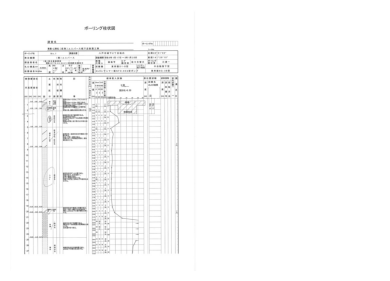

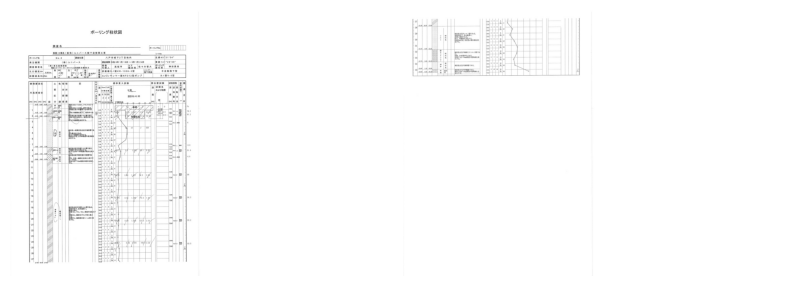

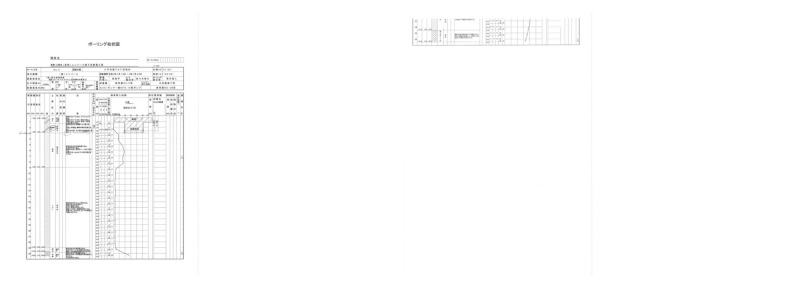

In [17]:
plot_image_groups(groups)

In [17]:
image_test = groups[1]
image_test = [image_array_to_png_bytes(img) for img in image_test]

result = transform_images_to_json(image_test, instruction_path="boring_instrucitons.txt", max_output_tokens=30000)
print(json.dumps(result, ensure_ascii=False, indent=2))

{
  "$schema": "http://json-schema.org/draft-07/schema#",
  "title": "Borehole Log Extraction",
  "type": "object",
  "borehole_log": {
    "header_info": {
      "investigation_name": null,
      "project_name": "(仮称)ユニバース城下店新築工事",
      "borehole_no": "No.2",
      "sheet_no": null,
      "location": "八戸市城下2丁目地内",
      "client": "(株)ユニバース",
      "contractor": "(株)東北基礎調査",
      "chief_engineer": "加藤政文",
      "investigation_period_start": "2023-01-18",
      "investigation_period_end": "2023-01-24",
      "collar_elevation_el_m": 5.951,
      "total_depth_m": 35.45,
      "drilling_machine": "KR-100H-3型",
      "engine": "ヤンマー製 NFD12型",
      "hammer_device": "半自動落下型",
      "pump": "カノ製 V-5型"
    },
    "soil_layers": [
      {
        "start_depth_m": 0.0,
        "end_depth_m": 0.2,
        "layer_thickness_m": 0.2,
        "soil_classification": "盛土",
        "color": "暗灰",
        "description": "深度0.00m~0.03m、アスファルトである。\n深度0.03m~0.20m、砕石である。"
      },
      {
        "start_d